- Create a 2D mesh grid of feature space, simulate a binary classification model's predictions, and plot the decision surface using pcolormesh

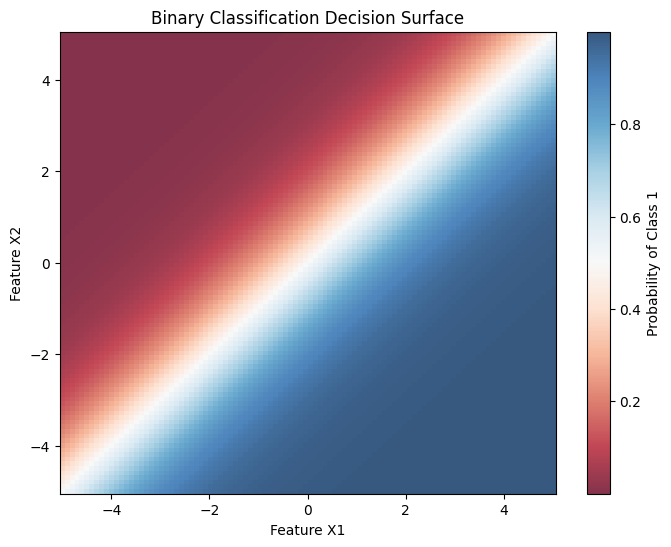

In [2]:
# --- Cell 3: Decision Surface Plotting ---
import matplotlib.pyplot as plt
import torch
import numpy as np

# Simulate a simple trained binary classifier
class DummyBinaryModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = torch.nn.Linear(2, 1)
        # Manually setting weights to create a diagonal decision boundary
        self.fc.weight.data = torch.tensor([[1.0, -1.0]]) 
        self.fc.bias.data = torch.tensor([0.0])
        
    def forward(self, x):
        return torch.sigmoid(self.fc(x))

model = DummyBinaryModel()

# 1. Create a grid of points (x1, x2) covering our feature space
x1_range = np.linspace(-5, 5, 100)
x2_range = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# 2. Flatten grid to pass through the model
grid_points = np.c_[X1.ravel(), X2.ravel()]
grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

# 3. Get predictions and reshape back to grid shape
with torch.no_grad():
    preds = model(grid_tensor).numpy()
preds = preds.reshape(X1.shape)

# 4. Plot using pcolormesh
plt.figure(figsize=(8, 6))
# cmap='RdBu' gives a nice Red (Class 0) to Blue (Class 1) gradient
c = plt.pcolormesh(X1, X2, preds, cmap='RdBu', shading='auto', alpha=0.8)
plt.colorbar(c, label='Probability of Class 1')
plt.title("Binary Classification Decision Surface")
plt.xlabel("Feature X1")
plt.ylabel("Feature X2")
plt.show()